In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

%matplotlib inline

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/Amazon sale report.csv")

In [4]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [5]:
df.shape

(128976, 21)

In [6]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

In [8]:
df.describe()

,index,Qty,Amount,ship-postal-code,New,PendingS
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


In [9]:
df.describe(include="object")

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,currency,ship-city,ship-state,ship-country,fulfilled-by
count,128976,128976,128976,128976,128976,128976,128976,128976,128976,121176,128941,128941,128941,39263
unique,120229,91,13,2,2,2,9,11,4,1,8948,69,1,1
top,403-4984515-8861958,05-03-2022,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,INR,BENGALURU,MAHARASHTRA,IN,Easy Ship
freq,12,2085,77815,89713,128852,88630,50292,22373,109486,121176,11208,22272,128941,39263


In [10]:
df.isnull().sum()

index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(168)

In [12]:
# Remove completely empty columns
df.drop(columns=["New", "PendingS"], inplace=True)

In [13]:
df.shape

(128976, 19)

In [14]:
df[df["Amount"].isnull()].head(10)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
8,8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,3XL,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,False,NaN
29,29,404-5933402-8801952,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Shirt,3XL,On the Way,0,NaN,NaN,GUWAHATI,ASSAM,781003.0,IN,False,Easy Ship
65,65,171-4137548-0481151,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,Shirt,XXL,Cancelled,0,NaN,NaN,Dahod,Gujarat,389151.0,IN,False,NaN
84,84,403-9950518-0349133,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,Shirt,M,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,500072.0,IN,False,NaN
95,95,405-9112089-3379536,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,Shirt,L,Cancelled,0,NaN,NaN,PUNE,MAHARASHTRA,411046.0,IN,False,NaN
101,101,402-7841951-1872363,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,S,Cancelled,0,NaN,NaN,NEW DELHI,DELHI,110036.0,IN,False,NaN
132,132,171-0293372-4913973,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,3XL,Cancelled,0,NaN,NaN,KOLAR,KARNATAKA,563101.0,IN,False,NaN
139,139,403-6442534-2769112,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,Trousers,3XL,Cancelled,0,NaN,NaN,AZAMGARH,UTTAR PRADESH,276302.0,IN,False,NaN
155,155,402-8078642-8565124,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,Shirt,XL,Cancelled,0,NaN,NaN,Puri-2,ODISHA,752002.0,IN,False,NaN
165,165,406-0218328-1773963,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,Shirt,6XL,Cancelled,0,NaN,NaN,WALAJAPET,TAMIL NADU,632513.0,IN,False,NaN


In [15]:
df[df["Amount"].isnull()]["Status"].value_counts()

Status
Cancelled                       7571
Shipped                          208
Shipped - Delivered to Buyer       8
Shipping                           8
Shipped - Returned to Seller       3
Pending                            2
Name: count, dtype: int64

In [16]:
df = df.dropna(subset=["Amount"])

In [17]:
df.shape

(121176, 19)

In [18]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Category                  0
Size                      0
Courier Status            0
Qty                       0
currency                  0
Amount                    0
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
B2B                       0
fulfilled-by          83649
dtype: int64

In [19]:
df["fulfilled-by"].value_counts(dropna=False)

fulfilled-by
NaN          83649
Easy Ship    37527
Name: count, dtype: int64

In [20]:
df[df["ship-city"].isnull()]

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
1872,1871,404-0566904-4825137,04-29-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,L,Shipped,1,INR,493.0,NaN,NaN,NaN,NaN,False,NaN
1873,1872,404-0566904-4825137,04-29-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,L,Shipped,1,INR,458.0,NaN,NaN,NaN,NaN,False,NaN
2090,1871,404-0566904-4825137,04-29-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,L,Shipped,1,INR,493.0,NaN,NaN,NaN,NaN,False,NaN
2091,1872,404-0566904-4825137,04-29-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,L,Shipped,1,INR,458.0,NaN,NaN,NaN,NaN,False,NaN
8753,8752,406-4003386-8768363,04-25-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,M,Shipped,1,INR,432.0,NaN,NaN,NaN,NaN,False,NaN
11216,11215,402-0107720-7057168,04-23-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,S,Shipped,1,INR,654.0,NaN,NaN,NaN,NaN,False,NaN
13253,13252,407-4532637-8415521,04-22-22,Cancelled,Merchant,Amazon.in,Standard,Shirt,S,On the Way,0,INR,380.0,NaN,NaN,NaN,NaN,False,Easy Ship
15689,15688,404-9229894-8608305,04-21-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,M,Shipped,1,INR,442.0,NaN,NaN,NaN,NaN,False,NaN
16788,16787,402-4919636-4333150,04-20-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,376.0,NaN,NaN,NaN,NaN,False,Easy Ship
18352,18351,405-4927647-8064368,04-19-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,1,INR,1112.0,NaN,NaN,NaN,NaN,False,NaN


In [21]:
df["fulfilled-by"].value_counts(dropna=False)

fulfilled-by
NaN          83649
Easy Ship    37527
Name: count, dtype: int64

In [22]:
df["fulfilled-by"] = df["fulfilled-by"].fillna("Merchant")

In [23]:
df["fulfilled-by"].value_counts()

fulfilled-by
Merchant     83649
Easy Ship    37527
Name: count, dtype: int64

In [24]:
df.isnull().sum()

index                  0
Order ID               0
Date                   0
Status                 0
Fulfilment             0
Sales Channel          0
ship-service-level     0
Category               0
Size                   0
Courier Status         0
Qty                    0
currency               0
Amount                 0
ship-city             33
ship-state            33
ship-postal-code      33
ship-country          33
B2B                    0
fulfilled-by           0
dtype: int64

In [25]:
df["Date"] = pd.to_datetime(df["Date"])

C:\Users\Rkkha\AppData\Local\Temp\ipykernel_7644\936118274.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [26]:
df["Month"] = df["Date"].dt.month_name()

df["Year"] = df["Date"].dt.year

df["Day"] = df["Date"].dt.day_name()

In [27]:
df[["Date", "Month", "Year", "Day"]].head()

,Date,Month,Year,Day
0,2022-04-30,April,2022,Saturday
1,2022-04-30,April,2022,Saturday
2,2022-04-30,April,2022,Saturday
3,2022-04-30,April,2022,Saturday
4,2022-04-30,April,2022,Saturday


In [28]:
df.dropna(
    subset=[
        "ship-city",
        "ship-state",
        "ship-postal-code",
        "ship-country"
    ],
    inplace=True
)

In [29]:
df.isnull().sum()

index                 0
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Category              0
Size                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
B2B                   0
fulfilled-by          0
Month                 0
Year                  0
Day                   0
dtype: int64

# Exploratory Data Analysis (EDA) on Amazon Sales Dataset

## Dataset Overview (KPIs)

In [37]:
# KPIs

total_orders = len(df)

total_revenue = df["Amount"].sum()

average_order = df["Amount"].mean()

total_quantity = df["Qty"].sum()

highest_order = df["Amount"].max()

lowest_order = df["Amount"].min()

print(f"Total Orders: {total_orders:,}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{average_order:.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Highest Order Value: ₹{highest_order}")
print(f"Lowest Order Value: ₹{lowest_order}")

Total Orders: 121,143
Total Revenue: ₹78,570,548.25
Average Order Value: ₹648.58
Total Quantity Sold: 116,449
Highest Order Value: ₹5584.0
Lowest Order Value: ₹0.0


### Order Status Distribution

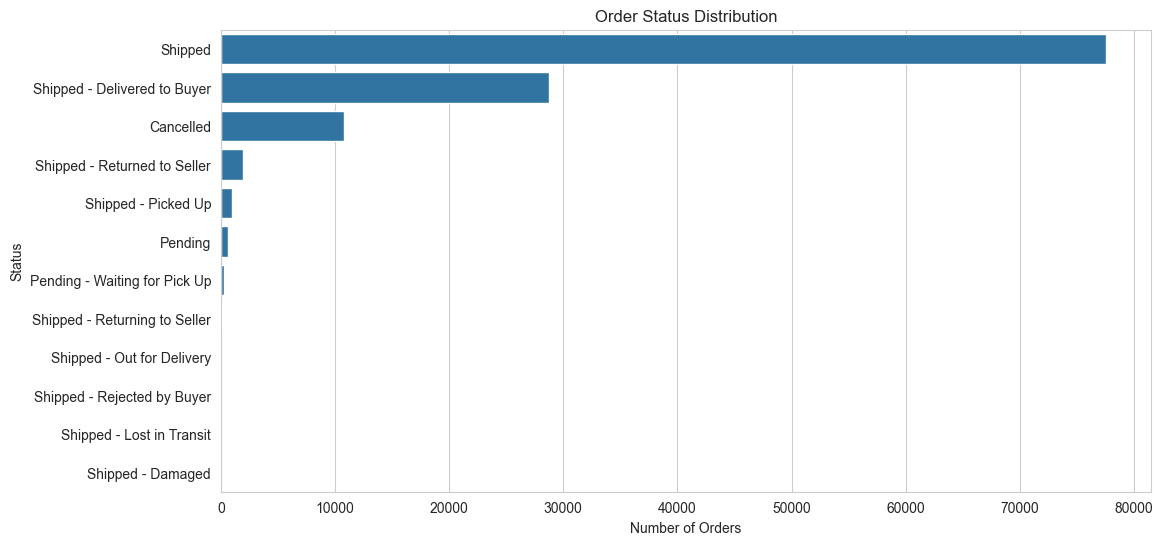

In [38]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Status",
    order=df["Status"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Status")

plt.show()

**Insight**

- Identify the most common order status.
- Observe the proportion of cancelled or returned orders.
- This helps evaluate order fulfillment efficiency.

### Product Category Distribution

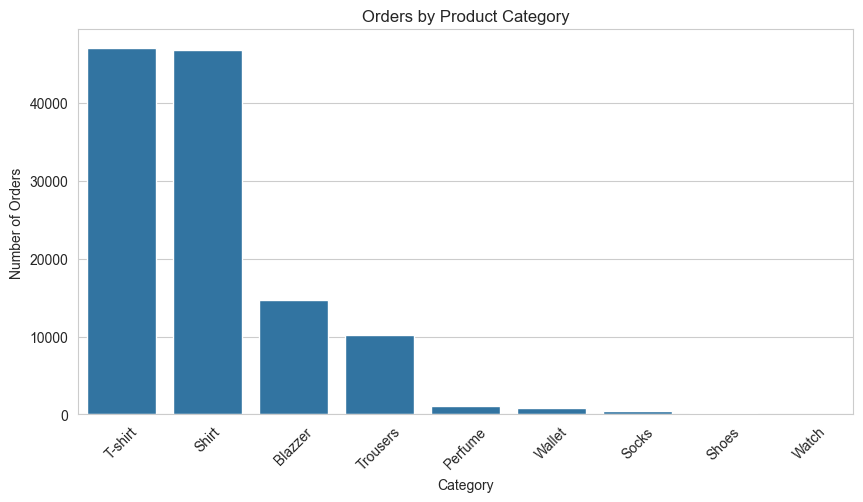

In [40]:
plt.figure(figsize=(10,5))

category_count = df["Category"].value_counts()

sns.barplot(
    x=category_count.index,
    y=category_count.values
)

plt.xticks(rotation=45)

plt.title("Orders by Product Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.show()

### Which category generates the highest revenue?

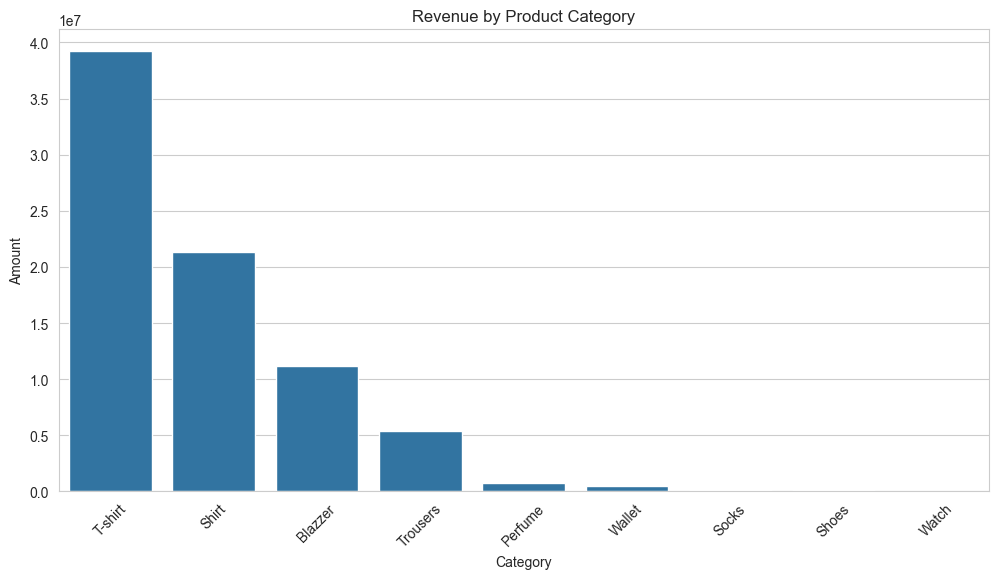

In [41]:
category_sales = (
    df.groupby("Category")["Amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=category_sales,
    x="Category",
    y="Amount"
)

plt.xticks(rotation=45)

plt.title("Revenue by Product Category")

plt.show()

### Which states generate the highest revenue?

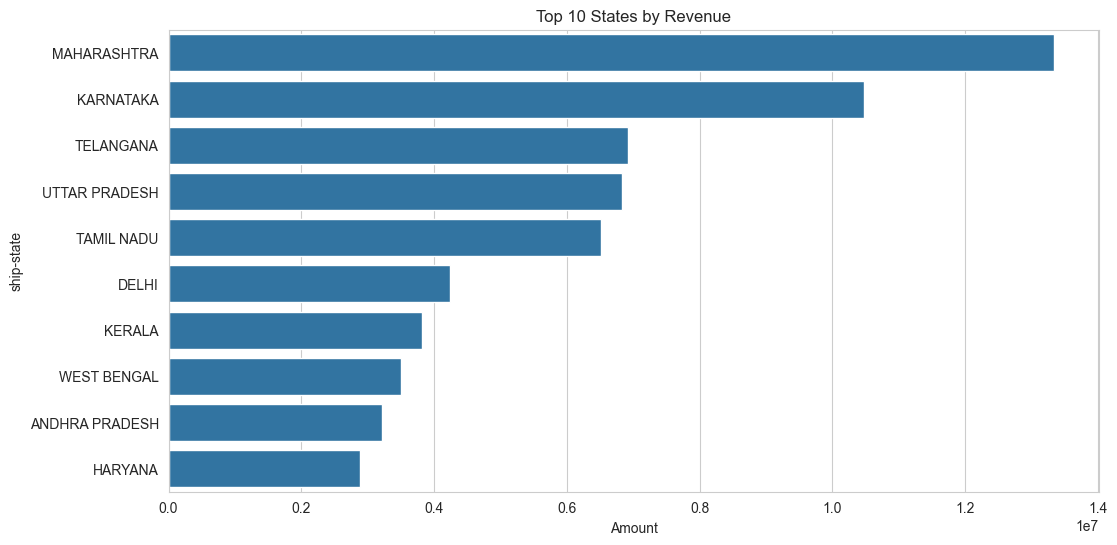

In [42]:
state_sales = (
    df.groupby("ship-state")["Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=state_sales,
    x="Amount",
    y="ship-state"
)

plt.title("Top 10 States by Revenue")

plt.show()

### Which cities receive the highest number of orders?

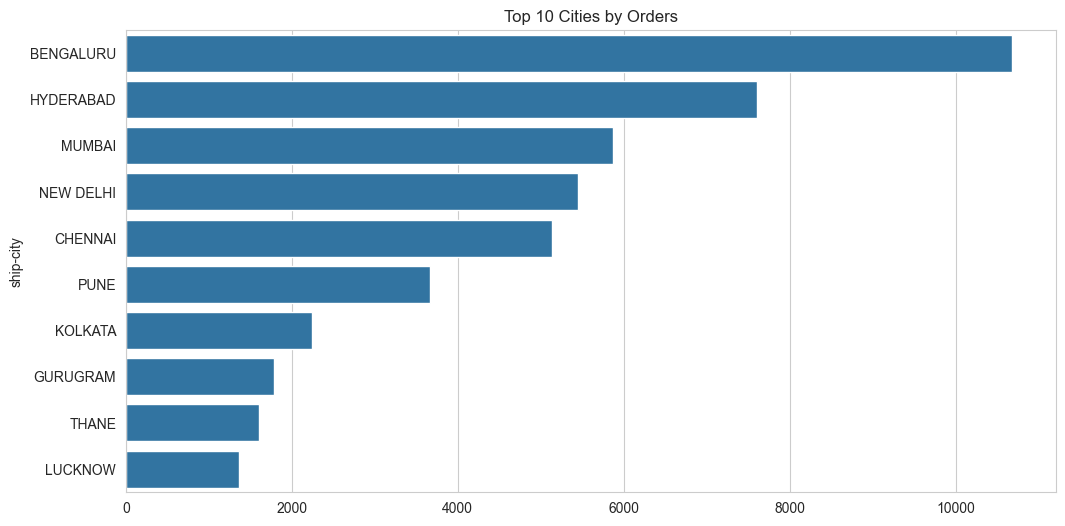

In [43]:
top_city = (
    df["ship-city"]
      .value_counts()
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_city.values,
    y=top_city.index
)

plt.title("Top 10 Cities by Orders")

plt.show()

### How do sales change over months?

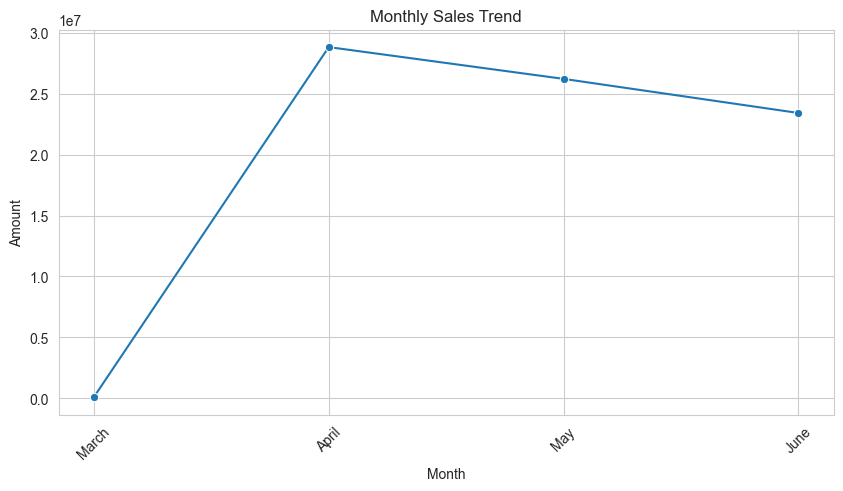

In [44]:
monthly_sales = (
    df.groupby("Month")["Amount"]
      .sum()
      .reset_index()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales["Month"] = pd.Categorical(
    monthly_sales["Month"],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values("Month")

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Amount",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")

plt.show()

### Which product sizes are most popular?

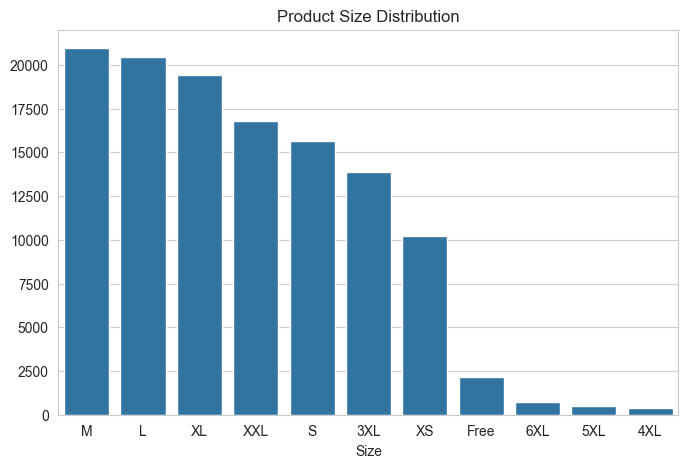

In [45]:
plt.figure(figsize=(8,5))

size_count = df["Size"].value_counts()

sns.barplot(
    x=size_count.index,
    y=size_count.values
)

plt.title("Product Size Distribution")

plt.show()

### Relationship between Quantity and Sales Amount

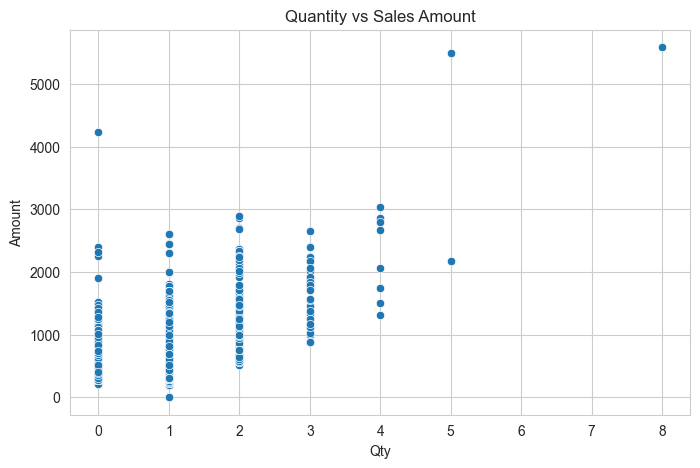

In [46]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Qty",
    y="Amount"
)

plt.title("Quantity vs Sales Amount")

plt.show()

### Correlation between numerical variables

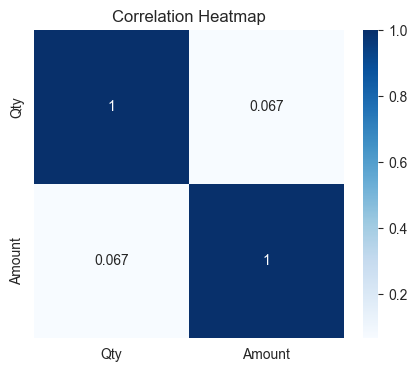

In [47]:
plt.figure(figsize=(5,4))

sns.heatmap(
    df[["Qty","Amount"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()